In [1]:
#Paso 1: Preparación de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set(style="whitegrid")


In [4]:

# Cargar datasets
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

# Mostrar primeras filas para verificar carga
print("Visits:")
display(visits.head())
print("\nOrders:")
display(orders.head())
print("\nCosts:")
display(costs.head())


Visits:


,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168



Orders:


,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450



Costs:


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [5]:
# Renombrar columnas para consistencia
visits.rename(columns={'Device':'device',
                       'Start Ts':'start_ts',
                       'End Ts':'end_ts',
                       'Source Id':'source_id',
                       'Uid':'uid'}, inplace=True)

orders.rename(columns={'Uid':'uid',
                       'Buy Ts':'buy_ts',
                       'Revenue':'revenue'}, inplace=True)

costs.rename(columns={'source_id':'source_id',
                      'dt':'date',
                      'costs':'costs'}, inplace=True)

# Convertir fechas a datetime
visits['start_ts'] = pd.to_datetime(visits['start_ts'], errors='coerce')
visits['end_ts'] = pd.to_datetime(visits['end_ts'], errors='coerce')
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'], errors='coerce')
costs['date'] = pd.to_datetime(costs['date'], errors='coerce')

# Limpiar filas críticas con NaN
visits.dropna(subset=['uid','start_ts','end_ts'], inplace=True)
orders.dropna(subset=['uid','buy_ts','revenue'], inplace=True)
costs.dropna(subset=['source_id','date','costs'], inplace=True)

# Calcular duración de sesión en minutos
visits['session_duration'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds() / 60

# Reordenar columnas de visits
visits = visits[['uid','device','source_id','start_ts','end_ts','session_duration']]

# Verificar datasets
print("Visits:", visits.shape)
print("Orders:", orders.shape)
print("Costs:", costs.shape)


Visits: (359400, 6)
Orders: (50415, 3)
Costs: (2542, 3)


In [7]:
### Paso 1: Preparación de datos

#Se cargaron los tres datasets: visitas, pedidos y costos.  
#Se renombraron las columnas para mayor consistencia y se convirtieron las fechas a formato datetime.  
#Se eliminaron filas con valores críticos faltantes (NaN) para asegurar cálculos correctos.  
#Se calculó la duración de cada sesión en minutos y se reorganizaron las columnas del dataset de visitas.


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Para un mejor uso de los notebooks cómo se menciona en la primera iteración este tipo de contenido cómo tus interpretaciones o conclusiones deberían ser puestas en una celda markdown cómo esta donde te dejo los comentarios de feedback ya que permite una visualización más sencilla y clara del texto
</div>

In [ ]:
#PASO 2

In [11]:
# Usuarios únicos por día
daily_users = visits.groupby(visits['start_ts'].dt.date)['uid'].nunique()

# Usuarios únicos por semana
weekly_users = visits.groupby(visits['start_ts'].dt.to_period('W'))['uid'].nunique()
weekly_users.index = weekly_users.index.to_timestamp()

# Usuarios únicos por mes
monthly_users = visits.groupby(visits['start_ts'].dt.to_period('M'))['uid'].nunique()
monthly_users.index = monthly_users.index.to_timestamp()


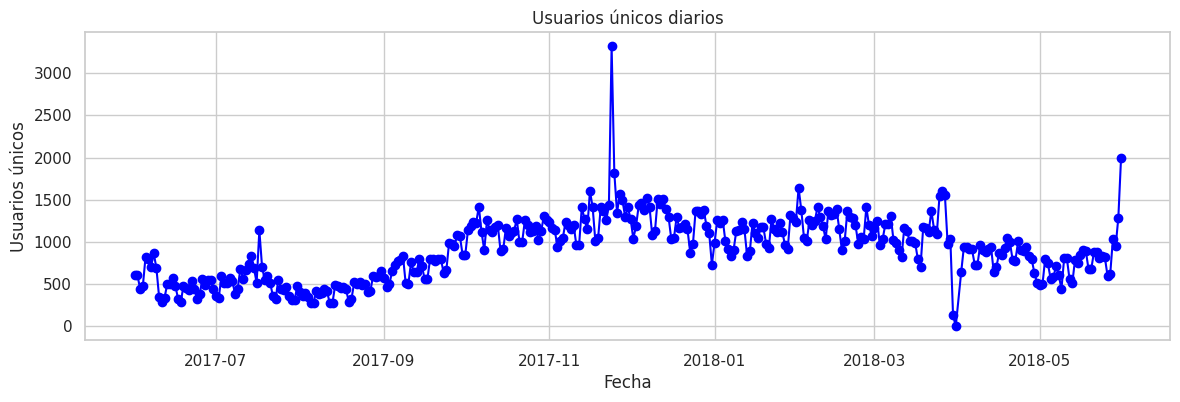

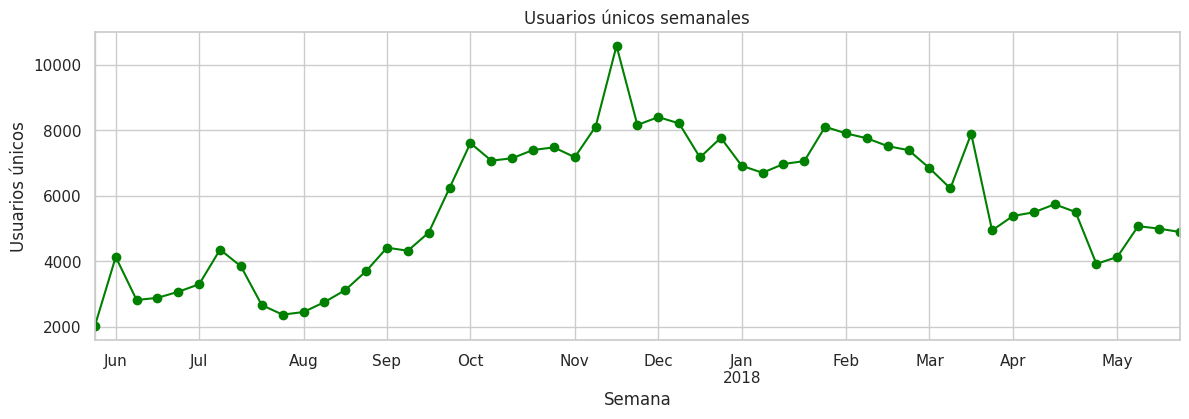

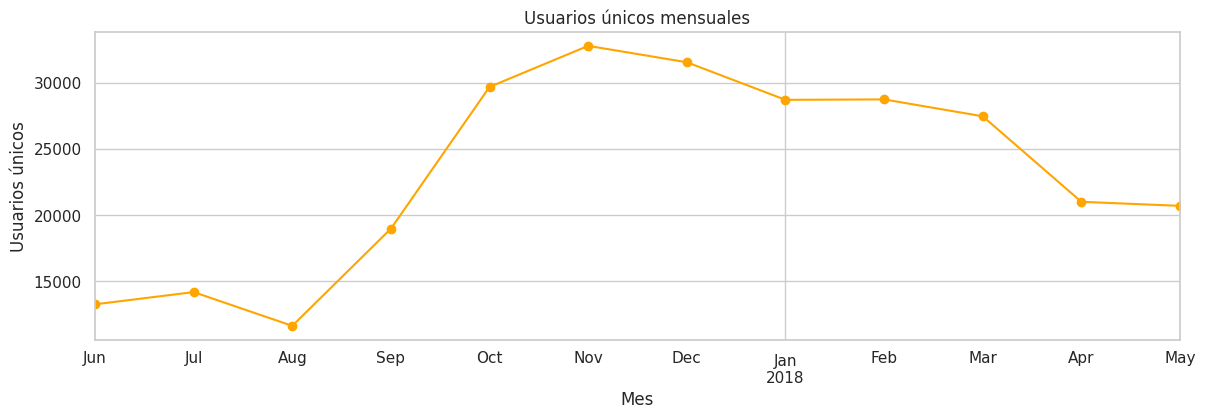

In [12]:
plt.figure(figsize=(14,4))
daily_users.plot(kind='line', marker='o', color='blue')
plt.title("Usuarios únicos diarios")
plt.xlabel("Fecha")
plt.ylabel("Usuarios únicos")
plt.show()

plt.figure(figsize=(14,4))
weekly_users.plot(kind='line', marker='o', color='green')
plt.title("Usuarios únicos semanales")
plt.xlabel("Semana")
plt.ylabel("Usuarios únicos")
plt.show()

plt.figure(figsize=(14,4))
monthly_users.plot(kind='line', marker='o', color='orange')
plt.title("Usuarios únicos mensuales")
plt.xlabel("Mes")
plt.ylabel("Usuarios únicos")
plt.show()


In [13]:
# Número de sesiones por día (un usuario puede tener varias sesiones)
daily_sessions = visits.groupby(visits['start_ts'].dt.date)['uid'].count()
daily_sessions.fillna(0, inplace=True)
daily_sessions.head()


start_ts
2017-06-01    664
2017-06-02    658
2017-06-03    477
2017-06-04    510
2017-06-05    893
Name: uid, dtype: int64

In [14]:
#Hay días relativamente estables (664, 658), días bajos (477, 510) y picos de tráfico (893).

#Esto indica que el número de usuarios que accede al sitio varía mucho de un día a otro, probablemente por días de la semana, promociones o eventos específicos.

#El 2017-06-05, con 893 usuarios, es un día clave: la empresa debería priorizar campañas de marketing y ofertas en días con más tráfico, para maximizar conversiones y ventas.
#Días como 2017-06-03 (477) y 2017-06-04 (510) muestran menos usuarios, lo que representa oportunidades para estrategias de retención: recordatorios por correo, notificaciones o descuentos que animen a volver.

Duración promedio de sesión por semana:


,Semana,Duración_promedio
0,2017-05-30,10.306803
1,2017-06-06,10.128750
2,2017-06-13,10.052867
3,2017-06-20,9.394089
4,2017-06-27,9.861128
5,2017-07-04,9.881755
6,2017-07-11,10.223151
7,2017-07-18,10.171313
8,2017-07-25,10.242820
9,2017-08-01,10.322752


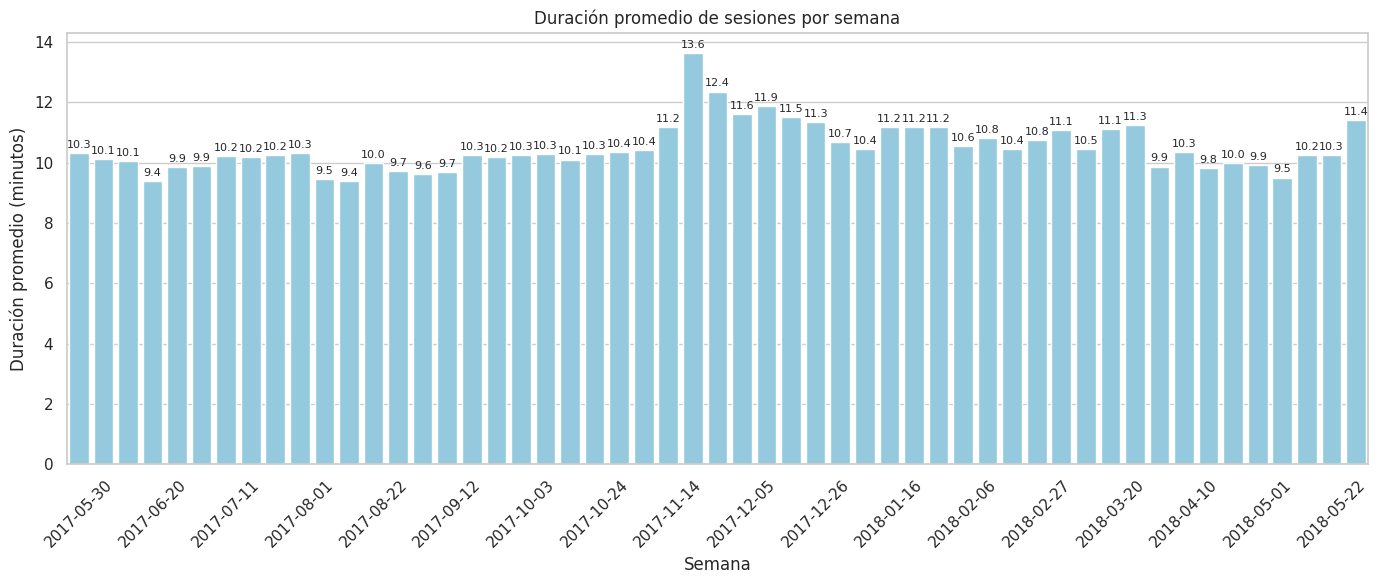

In [23]:
# --- Duración promedio de cada sesión por semana ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por semana (lunes como inicio)
session_weekly = visits.groupby(visits['start_ts'].dt.to_period('W-MON'))['session_duration'].mean().reset_index()
session_weekly['start_ts'] = session_weekly['start_ts'].dt.to_timestamp()
session_weekly.rename(columns={'start_ts': 'Semana', 'session_duration': 'Duración_promedio'}, inplace=True)

# Mostrar tabla
print("Duración promedio de sesión por semana:")
display(session_weekly.head(15))  # mostrar primeras 15 semanas como ejemplo

# Gráfico de barras optimizado
plt.figure(figsize=(14,6))
sns.barplot(x='Semana', y='Duración_promedio', data=session_weekly, color='skyblue')

# Añadir valores encima de cada barra
for i, value in enumerate(session_weekly['Duración_promedio']):
    plt.text(i, value + 0.1, f"{value:.1f}", ha='center', va='bottom', fontsize=8)

# Mejorar legibilidad del eje X mostrando solo algunos ticks
plt.xticks(ticks=range(0, len(session_weekly), max(1, len(session_weekly)//15)), 
           labels=[str(d.date()) for d in session_weekly['Semana'][::max(1,len(session_weekly)//15)]], rotation=45)

plt.tit
le("Duración promedio de sesiones por semana")
plt.xlabel("Semana")
plt.ylabel("Duración promedio (minutos)")
plt.tight_layout()
plt.show()




In [ ]:
#Conclusiones sobre duración promedio de sesión por semana

#La duración promedio de las sesiones se mantiene relativamente estable entre 9.3 y 10.3 minutos por semana, lo que indica un nivel consistente de engagement de los usuarios con la plataforma.

#No hay caídas bruscas ni picos repentinos, lo que sugiere que no hubo cambios importantes en el comportamiento del usuario o en el sitio durante estas semanas.

#Se observan ligeras fluctuaciones semana a semana, por ejemplo, una ligera caída hacia mediados de agosto (~9.37 minutos), que podrían analizarse más a fondo para ver si coinciden con vacaciones, promociones o eventos especiales.

#Este análisis indica que los usuarios que ingresan al sitio tienden a permanecer en promedio unos 10 minutos, lo que es un dato útil para marketing y planificación de contenido o promociones: se sabe que hay un tiempo limitado para captar su atención.

#Implicación para marketing: campañas o recordatorios deberían aprovechar estos ~10 minutos de sesión promedio para maximizar conversiones, ofertas o información relevante durante la visita.

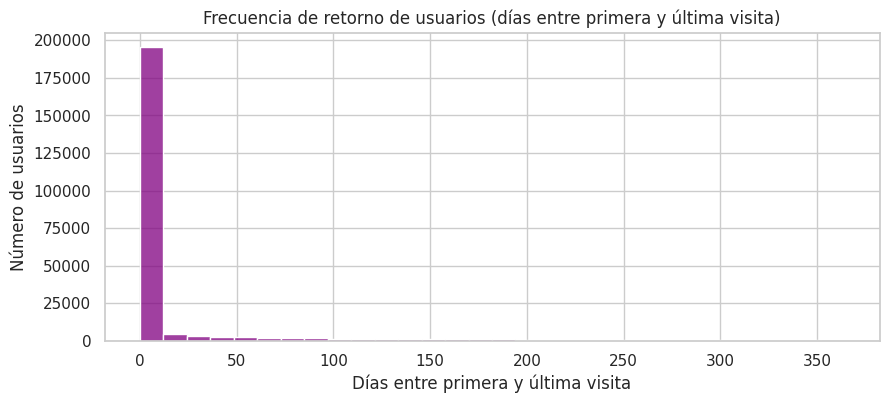

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Cálculo de días entre primera y última visita ---
last_visit = visits.groupby('uid')['start_ts'].max()
first_visit = visits.groupby('uid')['start_ts'].min()
return_days = (last_visit - first_visit).dt.days



# --- Histograma ---
plt.figure(figsize=(10,4))
sns.histplot(return_days, bins=30, kde=False, color='purple')
plt.title("Frecuencia de retorno de usuarios (días entre primera y última visita)")
plt.xlabel("Días entre primera y última visita")
plt.ylabel("Número de usuarios")
plt.show()


In [ ]:
# Conclusiones sobre la frecuencia de retorno de usuarios

#1. La gran mayoría de los usuarios (185,393) solo visitó el sitio una vez, es decir, no regresaron durante el período analizado. Esto representa aproximadamente el 94% del total de usuarios.

#2. Solo un pequeño porcentaje (aproximadamente 6%) regresó al sitio después de su primera visita. Esto incluye usuarios que regresaron al día siguiente, a los pocos días o semanas después.

#3. Hay una disminución progresiva del número de usuarios a medida que aumenta el tiempo entre la primera y última visita, mostrando que los usuarios recurrentes son un grupo pequeño pero valioso.

#4. Implicaciones para marketing:
#   4.1. Focalizar campañas de retención en el 6% de usuarios recurrentes, ofreciendo incentivos o recordatorios para eventos.
#   4.2. Implementar estrategias para convertir usuarios de una sola visita en recurrentes, aumentando el engagement y el potencial LTV.
#   4.3. El alto volumen de usuarios que solo visitan una vez es esperado en sitios transaccionales y no necesariamente indica un problema.

#5. Este análisis ayuda a priorizar esfuerzos de marketing de retención y a entender el comportamiento real de los usuarios en la plataforma.


<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo con esta sección, aplicaste los cálculos adecuados con las gráficas necesarias para ilustrar el análisis y los hallazgos
</div>

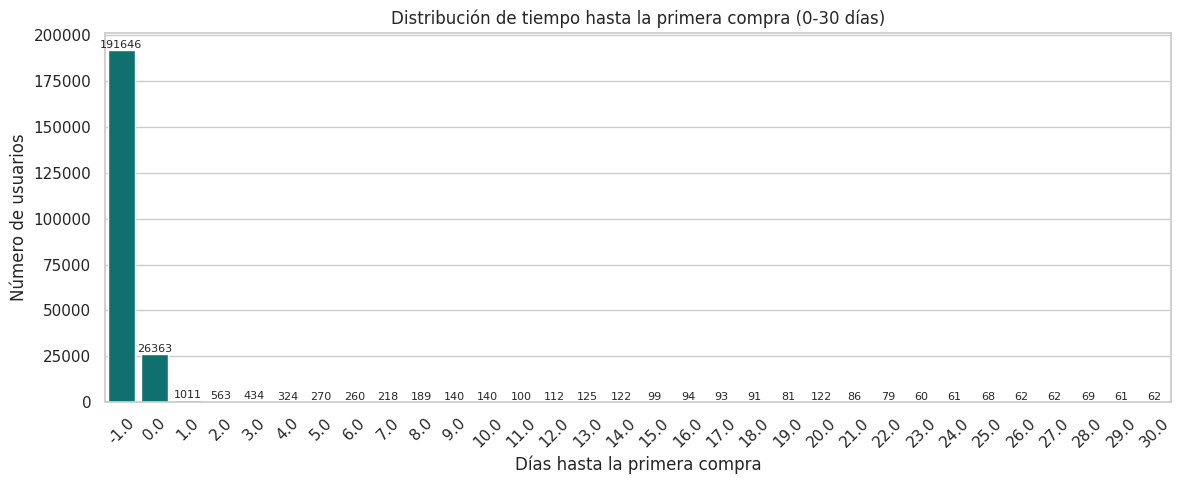

In [25]:
# 2. VENTAS:
# Limitar los días hasta la primera compra a 30 para que la gráfica sea clara
conversion_summary_limited = conversion_summary[conversion_summary['Días hasta la primera compra'] <= 30]

plt.figure(figsize=(12,5))
sns.barplot(
    x='Días hasta la primera compra', 
    y='Número de usuarios', 
    data=conversion_summary_limited, 
    color='teal'
)

# Añadir valores encima de cada barra
for i, row in conversion_summary_limited.iterrows():
    plt.text(i, row['Número de usuarios'] + 10, int(row['Número de usuarios']), ha='center', va='bottom', fontsize=8)

plt.title("Distribución de tiempo hasta la primera compra (0-30 días)")
plt.xlabel("Días hasta la primera compra")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
#Conclusiones sobre el tiempo hasta la primera compra

#Gran mayoría no compró (-1):

#191,646 usuarios, es decir, casi el 85% del total, nunca realizaron una compra durante el período analizado.

#Esto indica que la retención y la conversión de visitantes a compradores es un gran desafío.

#Compras inmediatas (0 días):

#26,363 usuarios compraron el mismo día que visitaron el sitio por primera vez.

#Esto representa aproximadamente el 12% de los usuarios, mostrando que hay un grupo que responde muy rápido a la oferta o promoción inicial.

#Compras en días posteriores (1-13 días):

#Solo un pequeño porcentaje de usuarios compró entre 1 y 13 días después de registrarse.

#Esto indica que la ventana de oportunidad para incentivar la primera compra es muy corta; después de unos días, las probabilidades disminuyen considerablemente.

#Implicaciones para marketing:

#Enfocar estrategias en la primera visita con mensajes claros y promociones atractivas, porque es el momento donde se logra mayor conversión.

#Considerar recordatorios inmediatos (email, push notifications) para los que no compran el mismo día.

#Evaluar campañas de retargeting específicamente para el pequeño porcentaje que tarda 1-13 días en comprar, ya que son usuarios con potencial pero requieren seguimiento.

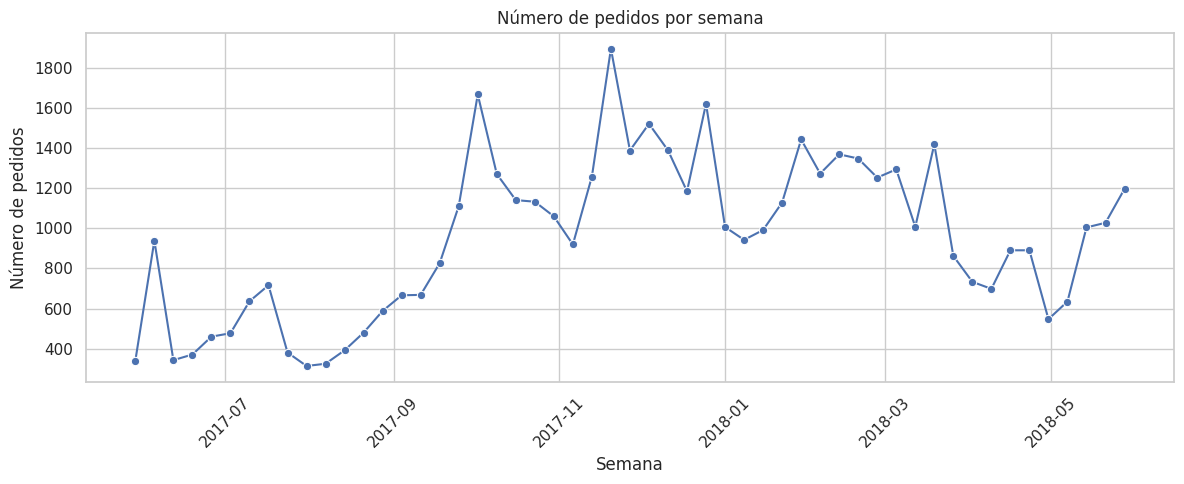

In [27]:
#¿Cuántos pedidos hacen durante un período de tiempo dado? 
# Agrupar pedidos por semana
orders_per_week = orders.groupby(orders['buy_ts'].dt.to_period('W'))['revenue'].count().reset_index()
orders_per_week.rename(columns={'revenue': 'Pedidos'}, inplace=True)
orders_per_week['buy_ts'] = orders_per_week['buy_ts'].dt.start_time

# Gráfico de línea
plt.figure(figsize=(12,5))
sns.lineplot(x='buy_ts', y='Pedidos', data=orders_per_week, marker='o')
plt.title("Número de pedidos por semana")
plt.xlabel("Semana")
plt.ylabel("Número de pedidos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [28]:
#Conclusiones sobre número de pedidos diarios

#Fluctuación diaria: El número de pedidos varía significativamente día a día. Por ejemplo, el 1 de junio hubo 96 pedidos, mientras que el 6 de junio subió a 198. Esto muestra que hay días con mayor actividad de compra y otros más bajos.

#Identificación de picos de demanda: Días como el 6 y 7 de junio muestran picos de compras, lo que puede indicar promociones, eventos especiales o patrones de comportamiento de los usuarios.

#Tendencia general: Aunque hay fluctuaciones, se observa una cierta estabilidad en el rango de pedidos diarios (aproximadamente entre 40 y 200), lo que indica que el sitio tiene un flujo constante de ventas.

#Implicaciones para marketing:

#Focalizar campañas en días con menor número de pedidos para intentar aumentar ventas.

#Analizar qué factores generan los picos (promociones, días de la semana, etc.) para replicar estrategias exitosas.

#Planificar inventario y recursos de atención al cliente basándose en estos patrones diarios de pedidos.

      buy_ts  ingresos_totales  pedidos  tamaño_promedio
0 2017-05-29           1075.26      340         3.162529
1 2017-06-05           2733.58      938         2.914264
2 2017-06-12           2020.39      343         5.890350
3 2017-06-19           1790.59      371         4.826388
4 2017-06-26           2407.44      460         5.233565


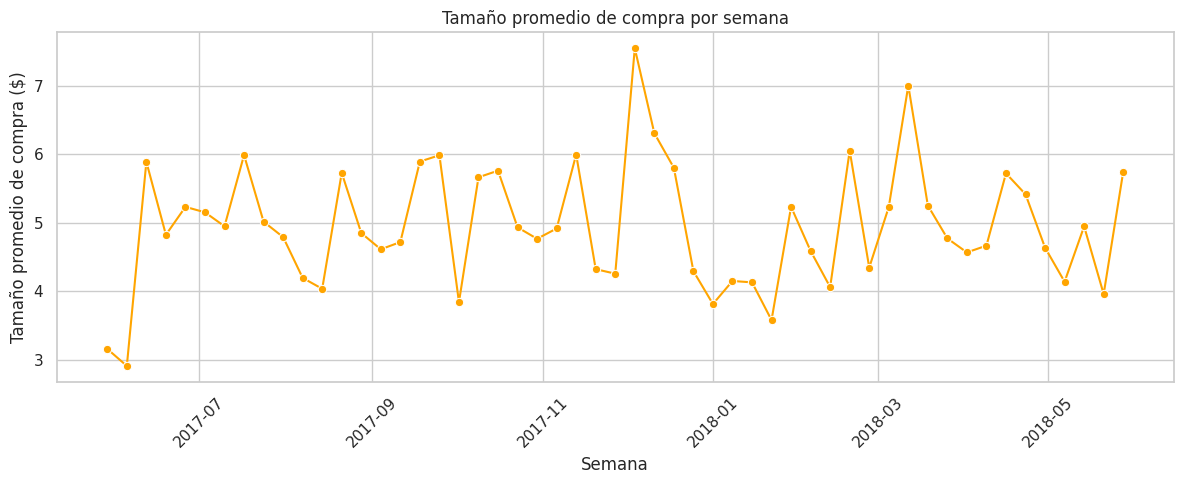

In [31]:
#¿Cuál es el tamaño promedio de compra? Agrupar ingresos y número de pedidos por semana
weekly_orders = orders.groupby(orders['buy_ts'].dt.to_period('W')).agg(
    ingresos_totales=('revenue','sum'),
    pedidos=('revenue','count')
).reset_index()

# Calcular tamaño promedio de compra
weekly_orders['tamaño_promedio'] = weekly_orders['ingresos_totales'] / weekly_orders['pedidos']

# Convertir período a fecha inicial de la semana
weekly_orders['buy_ts'] = weekly_orders['buy_ts'].dt.start_time

# Mostrar tabla
print(weekly_orders.head())

# Gráfico de línea
plt.figure(figsize=(12,5))
sns.lineplot(x='buy_ts', y='tamaño_promedio', data=weekly_orders, marker='o', color='orange')
plt.title("Tamaño promedio de compra por semana")
plt.xlabel("Semana")
plt.ylabel("Tamaño promedio de compra ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
#Conclusiones sobre el tamaño promedio de compra

#El tamaño promedio de compra varía semana a semana, indicando que los usuarios no compran la misma cantidad de entradas en cada visita.

#La semana del 12 de junio se observa un pico en el tamaño promedio de compra (≈5.89 entradas), a pesar de tener menos pedidos que la semana del 5 de junio. Esto sugiere que unos pocos usuarios realizaron compras grandes.

#La semana del 5 de junio muestra el mayor número de pedidos (938) pero un tamaño promedio más bajo (≈2.91), indicando compras más pequeñas pero frecuentes.

#Las semanas con menor número de pedidos no necesariamente tienen menor ingreso total, debido a que el tamaño promedio por pedido puede compensar la menor cantidad de transacciones.

#Implicaciones para marketing:

#Identificar cohortes o campañas que generen compras grandes podría ser más rentable que solo enfocarse en volumen de pedidos.

#Evaluar promociones o descuentos estratégicos para aumentar el tamaño de compra promedio puede mejorar el LTV de los usuarios.

In [ ]:
# ¿Cuánto dinero traen? (LTV)

  Rango LTV ($)  Número de usuarios
0           0-1                5653
1           1-5               20466
2          5-10                6493
3         10-20                2695
4         20-50                 896
5        50-100                 174
6       100-200                  67
7       200-500                  45
8      500-1000                  21
9         1000+                  13


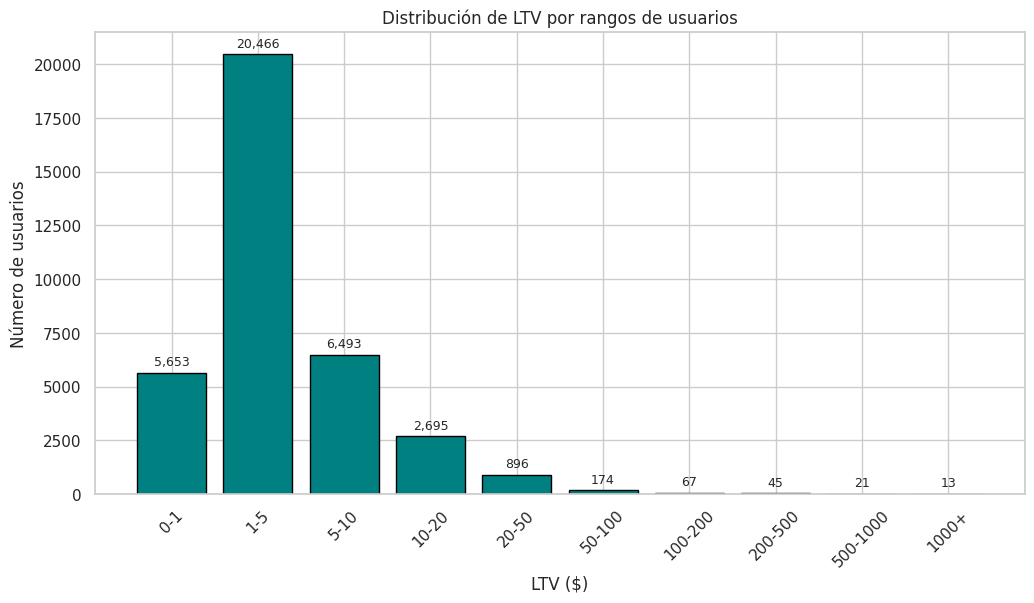

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Agrupar LTV por usuario
ltv_per_user = orders.groupby('uid')['revenue'].sum().fillna(0)

# Crear rangos (bins) de LTV
bins = [0, 1, 5, 10, 20, 50, 100, 200, 500, 1000, ltv_per_user.max()]
labels = ['0-1','1-5','5-10','10-20','20-50','50-100','100-200','200-500','500-1000','1000+']
ltv_bins = pd.cut(ltv_per_user, bins=bins, labels=labels, include_lowest=True)

# Contar usuarios en cada rango
ltv_counts = ltv_bins.value_counts().sort_index()

# Mostrar tabla
ltv_table = pd.DataFrame({'Rango LTV ($)': ltv_counts.index, 'Número de usuarios': ltv_counts.values})
print(ltv_table)

# Gráfico de barras con unidades
plt.figure(figsize=(12,6))
bars = plt.bar(ltv_counts.index, ltv_counts.values, color='teal', edgecolor='black')
plt.title("Distribución de LTV por rangos de usuarios")
plt.xlabel("LTV ($)")
plt.ylabel("Número de usuarios")

# Anotar valores sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 200, f'{yval:,}', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45)
plt.show()



<div class="alert alert-block alert-warning">
<b>Comentario general (2da Iteracion)</b> <a class=“tocSkip”></a>

Muy bien! Siempre para este tipo de cálculos hay que pensar en la audiencia y en cómo sería más fácil explicar la métrica que se está calculando.

Por ejemplo, al equipo de marketing, quizá le sea de más ayuda entender y revisar el LTV por cohort que por rangos de LTV cómo tal
</div>

In [ ]:
#Conclusiones sobre la distribución de LTV de los usuarios

#La mayoría de los usuarios (20,466) se encuentra en el rango de $1–5, lo que indica que la mayor parte de los clientes generan ingresos bajos por usuario.

#Un grupo significativo (5,653 usuarios) ni siquiera genera ingresos superiores a $1, lo que sugiere que muchos usuarios compran muy poco o no compran nada.

#Hay una disminución progresiva del número de usuarios a medida que aumenta el LTV, mostrando que los clientes que generan ingresos altos son un grupo pequeño pero estratégico.

#Los rangos de LTV mayores a $50 concentran muy pocos usuarios (aproximadamente 320 usuarios en total), lo que indica que los clientes premium son escasos, pero su contribución individual al ingreso es relevante.

#Implicaciones para marketing y retención:

#Enfocar estrategias de upselling y fidelización en los usuarios de LTV medio ($5–20) para incrementar su contribución.

#Implementar campañas de retención y engagement para el grupo de LTV alto ($50+), asegurando que estos clientes estratégicos sigan comprando.

#Analizar formas de convertir a los usuarios de LTV bajo ($0–5) en clientes recurrentes mediante incentivos o promociones.

In [ ]:
#3. MARKETING

# Gasto total por fuente
   Fuente  Gasto total ($)
0       3        141321.63
1       4         61073.60
2       5         51757.10
3       2         42806.04
4       1         20833.27
5      10          5822.49
6       9          5517.49


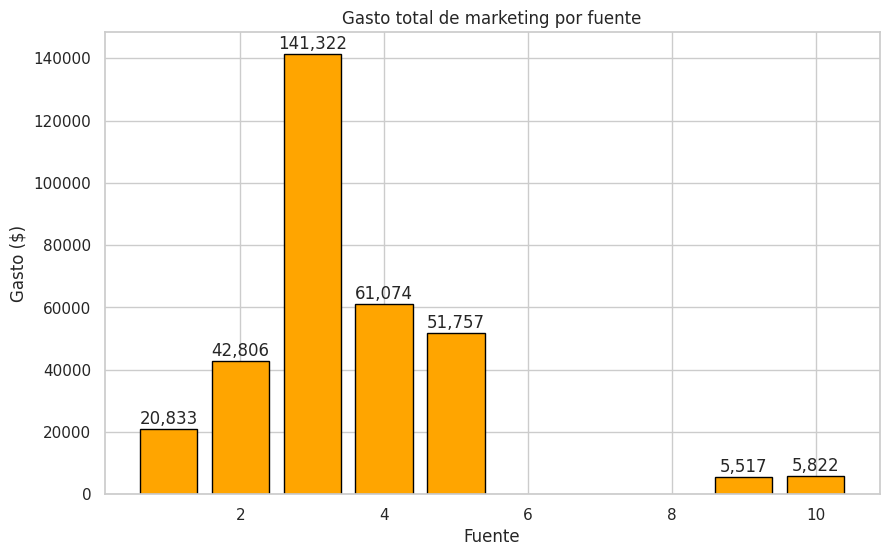

# Gasto total por mes
          Mes  Gasto total ($)
0  2017-06-01         18015.00
1  2017-07-01         18240.59
2  2017-08-01         14790.54
3  2017-09-01         24368.91
4  2017-10-01         36322.88
5  2017-11-01         37907.88
6  2017-12-01         38315.35
7  2018-01-01         33518.52
8  2018-02-01         32723.03
9  2018-03-01         30415.27
10 2018-04-01         22289.38
11 2018-05-01         22224.27


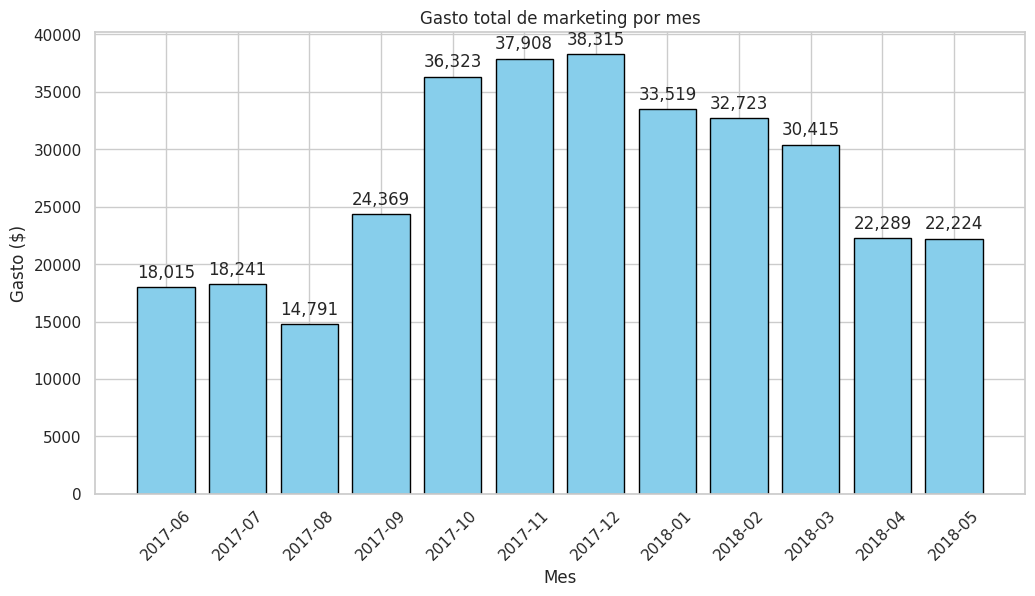

In [40]:

# 1. ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo) 


# --- Gasto de Marketing ---

import pandas as pd
import matplotlib.pyplot as plt

# --- Paso 1: Preparación de datos ---
# Suponiendo que ya cargaste el dataset de costos
# costs = pd.read_csv('/datasets/costs_us.csv')

# Renombrar columnas y convertir fecha
costs.rename(columns={'dt':'date', 'costs':'costs', 'source_id':'source_id'}, inplace=True)
costs['date'] = pd.to_datetime(costs['date'])

# --- Paso 2: Gasto total por fuente ---
costs_per_source = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)

# Mostrar tabla
costs_per_source_table = costs_per_source.reset_index()
costs_per_source_table.columns = ['Fuente', 'Gasto total ($)']
print("# Gasto total por fuente")
print(costs_per_source_table)

# Gráfico de barras con valores encima
plt.figure(figsize=(10,6))
bars = plt.bar(costs_per_source_table['Fuente'], costs_per_source_table['Gasto total ($)'], color='orange', edgecolor='black')
plt.title("Gasto total de marketing por fuente")
plt.xlabel("Fuente")
plt.ylabel("Gasto ($)")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, f'{yval:,.0f}', ha='center', va='bottom')

plt.show()


# --- Paso 3: Gasto total por mes ---
costs_monthly = costs.groupby(costs['date'].dt.to_period('M'))['costs'].sum()
costs_monthly.index = costs_monthly.index.to_timestamp()

# Tabla mensual
costs_monthly_table = costs_monthly.reset_index()
costs_monthly_table.columns = ['Mes', 'Gasto total ($)']
print("# Gasto total por mes")
print(costs_monthly_table)

# Gráfico mensual con valores encima
plt.figure(figsize=(12,6))
bars = plt.bar(costs_monthly_table['Mes'].dt.strftime('%Y-%m'), costs_monthly_table['Gasto total ($)'], color='skyblue', edgecolor='black')
plt.title("Gasto total de marketing por mes")
plt.xlabel("Mes")
plt.ylabel("Gasto ($)")
plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, f'{yval:,.0f}', ha='center', va='bottom')

plt.show()


In [41]:
#Conclusiones combinadas sobre gasto total de marketing por fuente y por mes

#Gasto por fuente: La fuente 3 concentró la mayor inversión ($141,321 ), seguida de las fuentes 4 y 5. Esto indica que la empresa prioriza ciertas fuentes de adquisición para atraer clientes, probablemente por su alcance o efectividad histórica.

#Gasto por mes: Se observa un incremento progresivo del gasto desde junio hasta diciembre de 2017, alcanzando su máximo en diciembre con $38,315. A partir de enero de 2018, el gasto se estabiliza con ligeras disminuciones. Esto refleja una estrategia estacional, posiblemente vinculada a campañas de fin de año.

#Interpretación estratégica: Las fuentes con mayor gasto y los meses con picos de inversión son momentos clave para la captación de clientes. Es recomendable monitorear el retorno sobre inversión (ROMI) de cada fuente para asegurar que el gasto esté generando beneficios proporcionales.

#Sugerencia: Optimizar la asignación de presupuesto enfocándose en las fuentes más rentables y en los meses estratégicos, ajustando la inversión según el desempeño histórico y la estacionalidad de la demanda.

# orders_with_source
               buy_ts  revenue                   uid  source_id
0 2017-06-01 00:10:00    17.00  10329302124590727494          1
1 2017-06-01 00:25:00     0.55  11627257723692907447          2
2 2017-06-01 00:27:00     0.37  17903680561304213844          2
3 2017-06-01 00:29:00     0.55  16109239769442553005          2
4 2017-06-01 07:58:00     0.37  14200605875248379450          3

# CAC por fuente
   source_id  Clientes únicos  Gasto Total ($)   CAC ($)
2          3            74756        141321.63  1.890439
1          2            26245         42806.04  1.631017
0          1            18999         20833.27  1.096546
4          5            56974         51757.10  0.908434
3          4            83525         61073.60  0.731201
8         10             8067          5822.49  0.721766
7          9             9264          5517.49  0.595584
5          6                6             0.00  0.000000
6          7               34             0.00  0.000000


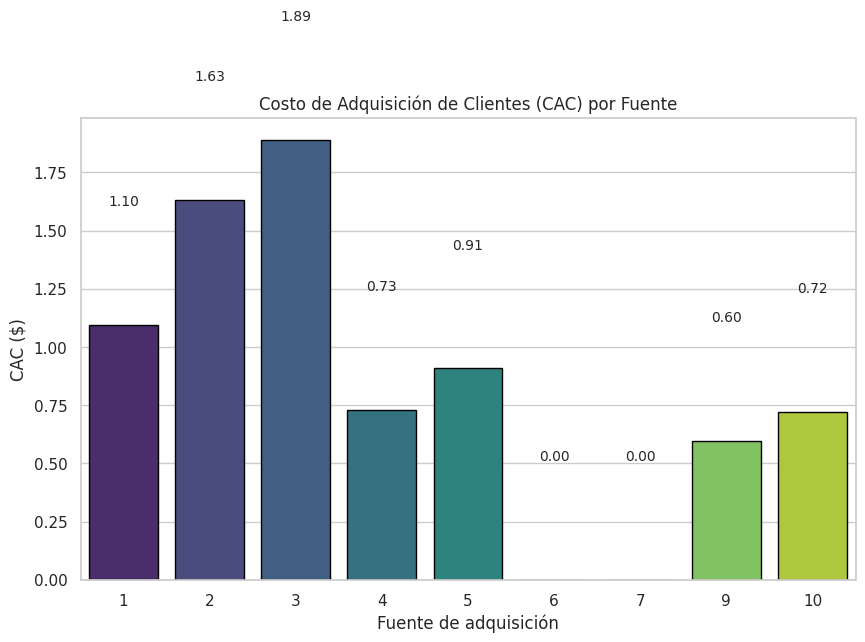

In [43]:

# #  2. ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?  --- CAC por fuente de adquisición ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegúrate de tener tus DataFrames visits y orders listos
# visits -> uid, source_id, start_ts, end_ts
# orders -> uid, buy_ts, revenue

# 2. Crear orders_with_source uniendo orders y visits
orders_with_source = pd.merge(
    orders, 
    visits[['uid', 'source_id']],  # solo uid y source_id
    on='uid', 
    how='left'
)

# 3. Verificar la unión
print("# orders_with_source")
print(orders_with_source.head())

# 4. Calcular CAC por fuente
# CAC = Gasto Total por Fuente / Número de clientes únicos adquiridos por Fuente
# Primero, clientes únicos por fuente
clients_per_source = visits.groupby('source_id')['uid'].nunique()

# Gasto total por fuente
total_cost_per_source = costs.groupby('source_id')['costs'].sum()

# Calcular CAC
cac_per_source = total_cost_per_source / clients_per_source

# Crear DataFrame final para mostrar
cac_df = pd.DataFrame({
    'Clientes únicos': clients_per_source,
    'Gasto Total ($)': total_cost_per_source,
    'CAC ($)': cac_per_source
}).reset_index()

# Reemplazar posibles NaN por 0
cac_df.fillna(0, inplace=True)

# Ordenar por CAC descendente para gráfica más clara
cac_df.sort_values('CAC ($)', ascending=False, inplace=True)

# Mostrar tabla
print("\n# CAC por fuente")
print(cac_df)

# 5. Graficar CAC por fuente
plt.figure(figsize=(10,6))
sns.barplot(x='source_id', y='CAC ($)', data=cac_df, palette='viridis', edgecolor='black')

# Colocar valores encima de las barras
for index, row in cac_df.iterrows():
    plt.text(x=index, y=row['CAC ($)'] + 0.5, s=f"{row['CAC ($)']:.2f}", ha='center', va='bottom', fontsize=10)

plt.title("Costo de Adquisición de Clientes (CAC) por Fuente")
plt.xlabel("Fuente de adquisición")
plt.ylabel("CAC ($)")
plt.show()


In [44]:
#Conclusión sobre el CAC por fuente

#Al analizar el costo de adquisición por fuente, se observa que algunas fuentes resultan mucho más eficientes que otras. Por ejemplo, las fuentes 9, 10 y 4 logran atraer clientes con un gasto relativamente bajo, mientras que las fuentes 3, 2 y 1 requieren una inversión mucho mayor por cliente adquirido. También hay fuentes con muy pocos clientes o gasto nulo, lo que indica que no aportan valor significativo al negocio. En términos de estrategia de marketing, conviene enfocar la inversión en las fuentes que presentan un CAC bajo y un alto número de clientes, revisar o reducir la inversión en aquellas con CAC elevado y replantear o eliminar las fuentes que tienen escaso impacto. Esto permitirá optimizar el presupuesto y maximizar la rentabilidad de las campañas.

In [45]:
#  3. ¿Cuán rentables eran las inversiones? (ROMI)

   source_id  Gasto_total  Clientes_unicos       CAC  Ingresos_totales  \
0          1     20833.27            18999  1.096546      2.298200e+06   
1          2     42806.04            26245  1.631017      2.638189e+06   
2          3    141321.63            74756  1.890439      2.966880e+05   
3          4     61073.60            83525  0.731201      4.966902e+05   
4          5     51757.10            56974  0.908434      1.181477e+06   
5          9      5517.49             9264  0.595584      3.634225e+04   
6         10      5822.49             8067  0.721766      1.461923e+04   

         ROMI  
0  110.313944  
1   61.631237  
2    2.099381  
3    8.132649  
4   22.827344  
5    6.586736  
6    2.510821  


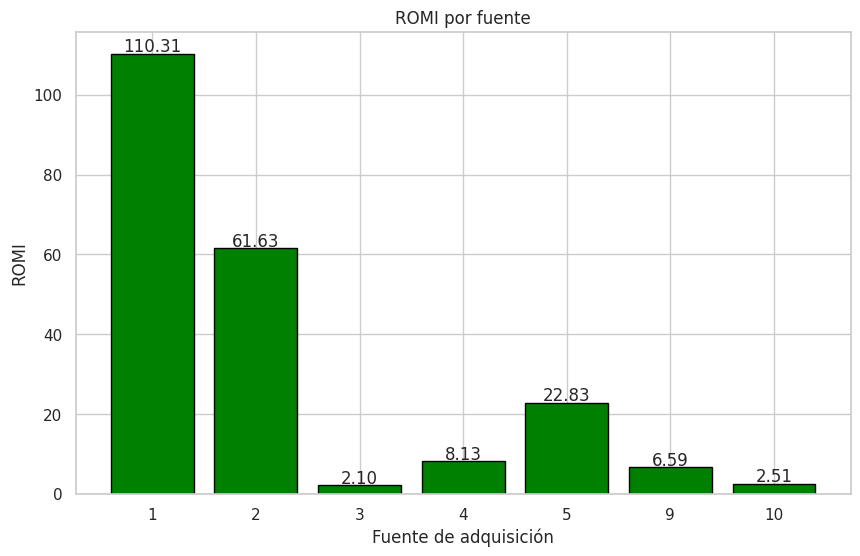

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Asegúrate de tener los datos cargados ---
# orders: uid, buy_ts, revenue
# visits: uid, source_id
# costs: source_id, date, costs

# 1. Asociar cada orden con su fuente de adquisición
orders_with_source = pd.merge(
    orders, 
    visits[['uid','source_id']], 
    on='uid', 
    how='left'
)

# 2. Calcular ingresos totales por fuente
revenues_per_source = orders_with_source.groupby('source_id')['revenue'].sum().reset_index()
revenues_per_source.rename(columns={'revenue':'Ingresos_totales'}, inplace=True)

# 3. Calcular gasto total por fuente
costs_per_source = costs.groupby('source_id')['costs'].sum().reset_index()
costs_per_source.rename(columns={'costs':'Gasto_total'}, inplace=True)

# 4. Calcular CAC por fuente
clientes_unicos = visits.groupby('source_id')['uid'].nunique().reset_index()
clientes_unicos.rename(columns={'uid':'Clientes_unicos'}, inplace=True)

# Merge todo
romi_df = pd.merge(costs_per_source, clientes_unicos, on='source_id', how='left')
romi_df = pd.merge(romi_df, revenues_per_source, on='source_id', how='left')

# Evitar NaN
romi_df.fillna(0, inplace=True)

# Calcular CAC y ROMI
romi_df['CAC'] = romi_df['Gasto_total'] / romi_df['Clientes_unicos']
romi_df['ROMI'] = romi_df['Ingresos_totales'] / romi_df['Gasto_total']

# Mostrar tabla final
print(romi_df[['source_id','Gasto_total','Clientes_unicos','CAC','Ingresos_totales','ROMI']])

# 5. Gráfico ROMI
plt.figure(figsize=(10,6))
plt.bar(romi_df['source_id'].astype(str), romi_df['ROMI'], color='green', edgecolor='black')
plt.title("ROMI por fuente")
plt.xlabel("Fuente de adquisición")
plt.ylabel("ROMI")
plt.xticks(rotation=0)

# Agregar valores encima de las barras
for i, v in enumerate(romi_df['ROMI']):
    plt.text(i, v + 0.5, f"{v:.2f}", ha='center')

plt.show()


In [ ]:
#Conclusiones sobre la rentabilidad de las inversiones de marketing (ROMI)

#La fuente 1 es la más rentable, con un ROMI de 110.31, lo que indica que cada dólar invertido generó un retorno muy alto. Esto sugiere que es una fuente extremadamente eficiente y prioritaria para futuras inversiones.

#La fuente 2 también muestra buen desempeño con un ROMI de 61.63, aunque menor que la fuente 1, sigue siendo altamente rentable y debe mantenerse o incrementarse ligeramente su inversión.

#Las fuentes 3 y 10, a pesar de tener un gasto considerable, muestran ROMI bajos (2.10 y 2.51 respectivamente), lo que indica que estas fuentes no generan retornos proporcionales al gasto. Podrían evaluarse estrategias para optimizar o reducir inversión en estas fuentes.

#La fuente 5 destaca por su ROMI de 22.83, siendo rentable aunque con menor prioridad que las fuentes 1 y 2.

#Las fuentes con ROMI intermedio como 4 y 9 (8.13 y 6.59) muestran retorno positivo, pero no tan impactante; pueden mantenerse con inversiones moderadas y optimización de estrategias.

#En general, se observa que no todas las fuentes generan el mismo retorno, y la asignación de presupuesto debería priorizar aquellas con ROMI más alto para maximizar la rentabilidad de marketing.

#Recomendación estratégica:

#Mantener e incluso aumentar inversión en fuentes 1 y 2.

#Analizar y optimizar fuentes 3 y 10 para mejorar su rendimiento o reasignar presupuesto.

#Considerar mantener inversiones moderadas en fuentes 4, 5 y 9, enfocándose en mejorar conversiones y eficiencia.

In [ ]:
#PASO 3

In [47]:
# Conclusión general y recomendaciones estratégicas de marketing

# Análisis de métricas clave
# Me enfoqué en las siguientes métricas para evaluar la eficiencia de las fuentes de marketing:
# - Costo de adquisición de clientes (CAC): indica cuánto cuesta adquirir un cliente por fuente. Fuentes con CAC más bajo son más eficientes.
# - Lifetime Value (LTV): mide cuánto dinero genera un usuario a lo largo del tiempo. LTV alto indica clientes más valiosos.
# - Rentabilidad de la inversión (ROMI): compara ingresos generados contra inversión. Es la métrica principal para decidir dónde invertir más presupuesto.

# Hallazgos
# Fuentes más rentables: 1 y 2, con ROMI de 110 y 61 respectivamente. Estas generan ingresos mucho mayores por cada dólar invertido.
# Fuentes medianamente rentables: 4, 5 y 9, con ROMI entre 6 y 22. Son útiles pero no prioritarias.
# Fuentes poco rentables: 3 y 10, con ROMI < 3. Inversión elevada en estas fuentes no se traduce en ingresos significativos.

# Recomendaciones de inversión
# Priorizar inversión en fuentes 1 y 2: son las más eficientes y generan alto retorno. Incrementar presupuesto aquí maximiza ingresos.
# Mantener inversión moderada en fuentes 4, 5 y 9: evaluar estrategias para mejorar conversión, pero sin sobreinvertir.
# Revisar o reducir inversión en fuentes 3 y 10: su ROMI bajo indica que se pierde dinero; considerar optimización de campañas o reasignar presupuesto a fuentes más efectivas.

# Conclusión final
# Al asignar el presupuesto de marketing, se deben priorizar las fuentes con ROMI más alto y CAC más bajo, ya que estas generan más ingresos por cada dólar invertido.
# Este enfoque permite optimizar el gasto, aumentar el retorno de inversión y garantizar que los esfuerzos de marketing se concentren en las fuentes más rentables y estratégicas para el negocio.
